# Class 22: SkyField Ephemerides
## Objective: Learn how to use details ephemerides for Solar System objects

These exercises are based on those in "Lecture 15: SkyField for Precision Ephemerides" by Yuan-Sen Ting and available from https://tingyuansen.github.io/coding_essential_for_astronomers/lectures/lecture15-skyfield-ephemerides.html

You will likely have to use conda to install SkyField. You can do this in a similar way to how you installed packages last week. The main difference is that SkyField is not in the `astropy` channel. I recommend using `conda-forge` instead. Open a terminal within JupyterLab and type the following: 

`install -c conda-forge skyfield`

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Set pandas display options for readable output
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 3)

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Basic libraries loaded")

from skyfield.api import load, wgs84
from skyfield import almanac

print("SkyField imported successfully!")

Basic libraries loaded
SkyField imported successfully!


## Section 1: Emphemeris 

JPL maintains multiple ephemeris datasets. We'll work with the DE440s ephemeris dataset. It is relatively small and covers from 1550-2650 CE with milli-arcsecond accuracy for planets and meter-level accuracy for the Moon. 

SkyField has its own time system. While the concepts are identical to astropy, the syntax is slightly different. The `Timescale` object handles leap seconds and conversions between time scales. 

In [14]:
# Load the DE440s ephemeris
eph = load('de440s.bsp')
print("Ephemeris loaded successfully")

# Access bodies using friendly names
sun = eph['sun']
earth = eph['earth']
moon = eph['moon']
mars = eph['mars barycenter']
jupiter = eph['jupiter barycenter']
saturn = eph['saturn barycenter']

print("Solar system bodies loaded successfully")

# Load the timescale
ts = load.timescale() # This loads the SkyField time system
print("Timescale loaded with current leap second data")

# Get current time from system clock
t_now = ts.now()
print(f"Current time (UTC): {t_now.utc_iso()}") # the .utc_iso() method reformats the SkyField Time object

# Create a specific time, for example to plan a future observation at the Summer Solstice: June 21, 2026 at 8:24 AM UTC

t = ts.utc(2026, 6, 21, 2, 8, 24) # standard clock adjusted by leap seconds
print(f"\nCreated time: {t.utc_iso()}")

# Create times with other standards
print(f"International Atomic Time: {ts.tai(2026, 3, 3, 2, 0, 0)}") # uniform, continuous atomic scale unaffected by leap seconds
print(f"Barycentric Dynamical Time: {ts.tdb(2026, 3, 3, 2, 0, 0)}") # accounts for reltivistic effects at the solar system barycenter


Ephemeris loaded successfully
Solar system bodies loaded successfully
Timescale loaded with current leap second data
Current time (UTC): 2026-03-06T19:05:16Z

Created time: 2026-06-21T02:08:24Z
International Atomic Time: <Time tt=2461102.583705833>
Barycentric Dynamical Time: <Time tt=2461102.583333317>


**Test your understanding:** 
Create a `Timescale` object and use it to define a time variable named `my_birthday` for your actual birthday (or another date, like the Apollo 11 landing on July 20, 1969 at 20:17). Print the result using the `.utc_jpl()` time object method, which converts a time instance into a formatted string used by NASA JPL. 

In [15]:
apollo11 = ts.utc(1969, 7, 20, 20, 17) # standard clock adjusted by leap seconds
print(f"Apollo 11 Landing: {apollo11.utc_jpl()}")
# Enter your code here 
myBirthday = ts.utc(2007, 1, 11, 8, 53)
print(f"My Birthday: {myBirthday.utc_jpl()}")

Apollo 11 Landing: A.D. 1969-Jul-20 20:17:00.0000 UTC
My Birthday: A.D. 2007-Jan-11 08:53:00.0000 UTC


## Section 2: Defining Observers and Targets

SkyField uses an intuitive syntax to compute the locations of solar system objects: 
`observer.at(time).observe(target)`. The observer is usually a location on Earth, the time is the time of observation, and the target is the celestial object. 

Let's compute and then visualize the path of Mars over the course of a year. Note that Mars mostly moves eastward, although there is a section where Mars appears to move backwards (westward). This phenomenon is called **retrograde motion** and it was a major puzzle prior to the development of the Copernican (heliocentric) model for the Solar System.

In [16]:
# Earth observes Mars at time t_now
astrometric = earth.at(t_now).observe(mars)
print("Computed Mars position as seen from Earth")

# Extract RA, Dec, and distance
ra, dec, distance = astrometric.radec()
print(f"Mars on {t_now.utc_iso()}:")
print(f"  Right Ascension: {ra}")
print(f"  Declination: {dec}")
print(f"  Distance: {distance.au:.6f} AU")

Computed Mars position as seen from Earth
Mars on 2026-03-06T19:05:16Z:
  Right Ascension: 22h 21m 11.27s
  Declination: -11deg 26' 30.6"
  Distance: 2.332951 AU


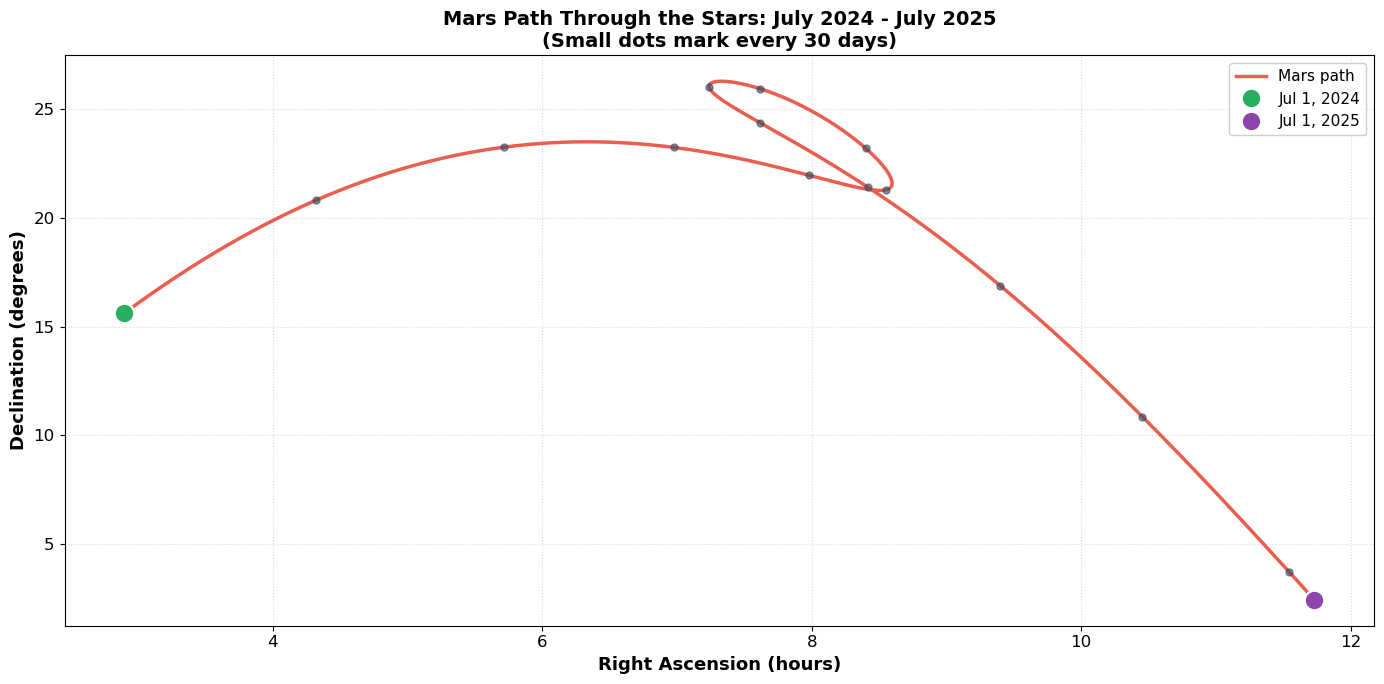

In [17]:
# Create daily times covering the 2024-2025 Mars retrograde period
days = np.arange(0, 396)  # 13 months = 396 days
times_year = ts.utc(2024, 7, 1 + days)

# Compute positions for all times at once (vectorized - very fast!)
positions = earth.at(times_year).observe(mars)
ra_year, dec_year, dist_year = positions.radec()

# Visualize the path of Mars
# Handle RA wrap-around at 24h/0h boundary using vectorized operations
# RA is circular: 23h59m → 0h00m, which creates plotting artifacts
# Instead of looping, we use np.diff() to compute all differences at once,
# then use cumulative sum to propagate the 24h shifts
ra_hours = ra_year.hours.copy()
ra_diff = np.diff(ra_hours, prepend=ra_hours[0])

# Identify where wraps occur (jumps > 12h or < -12h)
wrap_up = ra_diff > 12   # Jumped from ~23h to ~0h, need to add 24
wrap_down = ra_diff < -12  # Jumped from ~0h to ~23h, need to subtract 24

# Apply cumulative 24h shifts
shifts = np.cumsum(wrap_up.astype(int) * 24 - wrap_down.astype(int) * 24)
ra_hours = ra_hours + shifts

# Create the plot
plt.figure(figsize=(14, 7))
plt.plot(ra_hours, dec_year.degrees, color='#E74C3C', linewidth=2.5, 
         label='Mars path', alpha=0.9)
plt.plot(ra_hours[0], dec_year.degrees[0], 'o', color='#27AE60', 
         markersize=14, label='Jul 1, 2024', zorder=5, markeredgecolor='white', markeredgewidth=1.5)
plt.plot(ra_hours[-1], dec_year.degrees[-1], 'o', color='#8E44AD', 
         markersize=14, label='Jul 1, 2025', zorder=5, markeredgecolor='white', markeredgewidth=1.5)

# Mark every 30 days with small dots using vectorized indexing
marker_indices = np.arange(0, len(days), 30)
plt.plot(ra_hours[marker_indices], dec_year.degrees[marker_indices], 'o', 
         color='#34495E', markersize=5, alpha=0.6)

plt.xlabel('Right Ascension (hours)', fontsize=13, fontweight='bold')
plt.ylabel('Declination (degrees)', fontsize=13, fontweight='bold')
plt.title('Mars Path Through the Stars: July 2024 - July 2025\n(Small dots mark every 30 days)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best', framealpha=0.95)
plt.grid(alpha=0.3, linestyle=':', color='gray')
plt.tight_layout()
plt.show()

## Pedagogical illustration of retrograde motion

Retrograde motion occurs because the Earth moves faster in its orbit than Mars. When the Earth and Mars are nearly at inferior conjunction, Earth *passes* Mars and Mars appears to be moving backwards relative to the fixed stars.

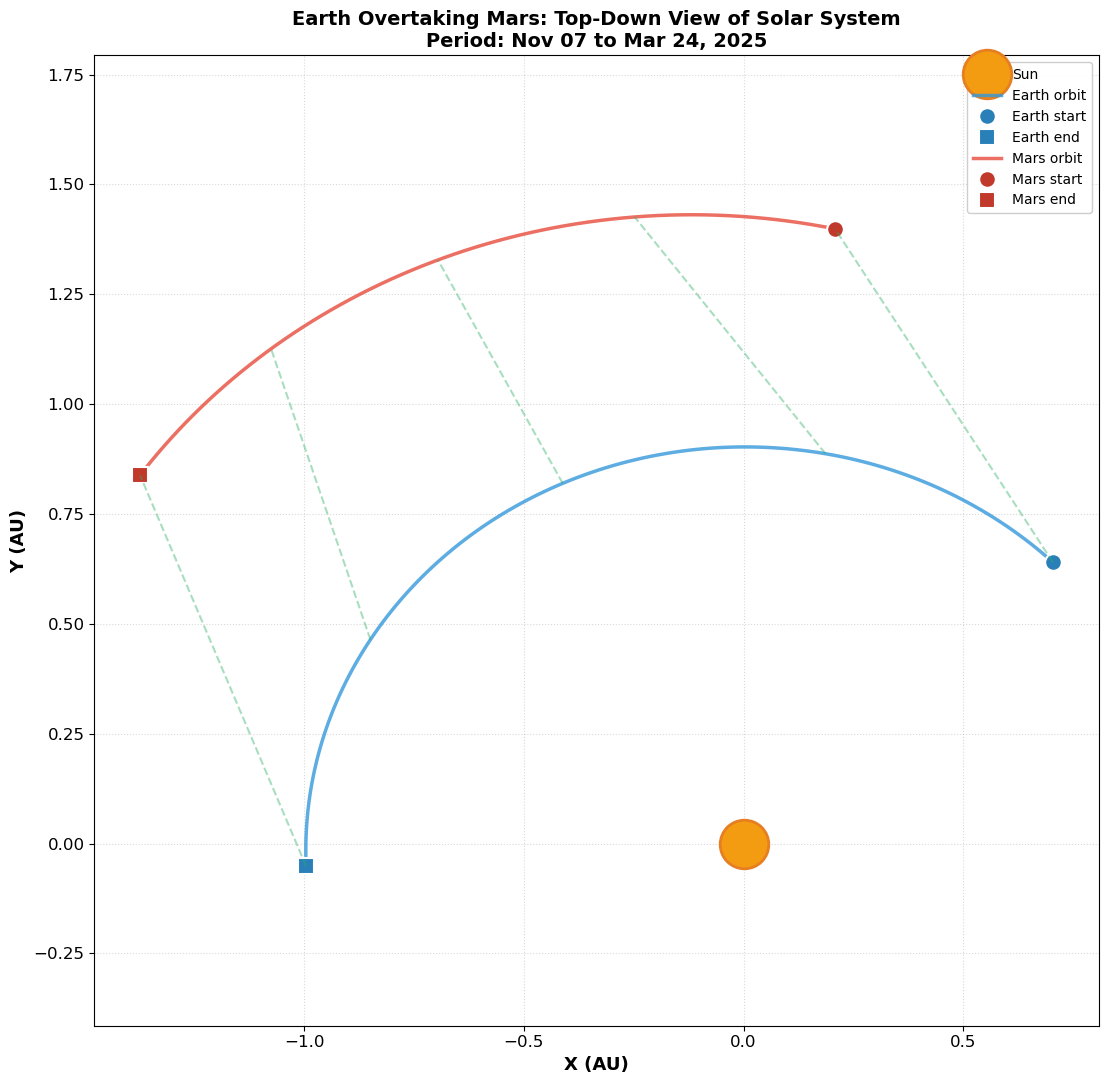

In [18]:
# Calculate daily velocity in RA (hours per day)
ra_velocity = np.diff(ra_year.hours)

# Handle RA wrap-around in velocity calculation
ra_velocity[ra_velocity > 12] -= 24
ra_velocity[ra_velocity < -12] += 24

# Classify motion: positive velocity = prograde, negative = retrograde
prograde = ra_velocity > 0
retrograde = ra_velocity < 0

# Find transition points where motion changes direction
# These occur where the sign of velocity changes
transitions = np.where(np.diff(np.sign(ra_velocity)))[0]

if len(transitions) >= 2:
    retro_start = transitions[0]
    retro_end = transitions[1]
    # Focus on ±30 days around retrograde for clarity
    start_idx = max(0, retro_start - 30)
    end_idx = min(len(days), retro_end + 30)
    times_retro = times_year[start_idx:end_idx]
    
    # Get Earth and Mars positions relative to the Sun
    earth_pos = sun.at(times_retro).observe(earth)
    mars_pos = sun.at(times_retro).observe(mars)
    earth_xyz = earth_pos.position.au
    mars_xyz = mars_pos.position.au
    
    plt.figure(figsize=(11, 11))
    
    # Plot Sun at center
    plt.plot(0, 0, 'o', color='#F39C12', markersize=35, label='Sun', zorder=5,
             markeredgecolor='#E67E22', markeredgewidth=2)
    
    # Plot Earth's orbital path
    plt.plot(earth_xyz[0], earth_xyz[1], color='#3498DB', linewidth=2.5, 
             label='Earth orbit', alpha=0.8)
    plt.plot(earth_xyz[0, 0], earth_xyz[1, 0], 'o', color='#2980B9', 
             markersize=12, label='Earth start', markeredgecolor='white', markeredgewidth=1.5)
    plt.plot(earth_xyz[0, -1], earth_xyz[1, -1], 's', color='#2980B9', 
             markersize=12, label='Earth end', markeredgecolor='white', markeredgewidth=1.5)
    
    # Plot Mars's orbital path
    plt.plot(mars_xyz[0], mars_xyz[1], color='#E74C3C', linewidth=2.5, 
             label='Mars orbit', alpha=0.8)
    plt.plot(mars_xyz[0, 0], mars_xyz[1, 0], 'o', color='#C0392B', 
             markersize=12, label='Mars start', markeredgecolor='white', markeredgewidth=1.5)
    plt.plot(mars_xyz[0, -1], mars_xyz[1, -1], 's', color='#C0392B', 
             markersize=12, label='Mars end', markeredgecolor='white', markeredgewidth=1.5)
    
    # Draw sight lines at key moments
    key_times = [0, len(times_retro)//4, len(times_retro)//2, 3*len(times_retro)//4, -1]
    for i in key_times:
        plt.plot([earth_xyz[0, i], mars_xyz[0, i]], 
                [earth_xyz[1, i], mars_xyz[1, i]], 
                color='#27AE60', linestyle='--', alpha=0.4, linewidth=1.5)
    
    plt.xlabel('X (AU)', fontsize=13, fontweight='bold')
    plt.ylabel('Y (AU)', fontsize=13, fontweight='bold')
    plt.title('Earth Overtaking Mars: Top-Down View of Solar System\n' + 
              f'Period: {times_retro[0].utc_strftime("%b %d")} to {times_retro[-1].utc_strftime("%b %d, %Y")}',
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='best', framealpha=0.95)
    plt.grid(alpha=0.3, linestyle=':', color='gray')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

## Section 3: Local Sky and Precise Positions

In SkyField, you can define your location on Earth using the **WGS84** ellipsoid (the standard for GPS). You also need to select which celestial body you want to "look" at from the ephemeris you loaded.

**WGS84** is World Geodetic System 1984. It is the standard ellipsoidal model of the Earth used by GPS and most other map applications. This is important because the Earth is a rotationally-flattened ellipsoid, not a perfect sphere.

SkyField uses two types of positions. **Astrometric** is the true direction (in the absence of atmospheric refraction and **Apparent** takes into account atmospheric refraction, which bends rays more and more and higher and higher airmass.

In [19]:
from skyfield.api import wgs84

t_now = ts.now() # set the time from the system clock

# Earth observes Mars at time t
astrometric = earth.at(t).observe(mars)
print("Computed Mars position as seen from Earth")

# Define Columbus, Ohio (same coordinates as Lecture 14)
columbus_lat = 39.9612   # degrees North
columbus_lon = -83.0003  # degrees East (negative = West)
columbus_elev = 260      # meters above sea level

# Create topocentric observer for .observe() calls
columbus = earth + wgs84.latlon(columbus_lat, columbus_lon, elevation_m=columbus_elev)

# Create separate Topos object for almanac functions
columbus_topos = wgs84.latlon(columbus_lat, columbus_lon, elevation_m=columbus_elev)

print(f"Observer location defined: Columbus, Ohio")
print(f"  Latitude:  {columbus_lat}° N")
print(f"  Longitude: {columbus_lon}° (West)")
print(f"  Elevation: {columbus_elev} m above sea level")

# Observe Mars from Columbus at our time
topocentric = columbus.at(t_now).observe(mars)
apparent = topocentric.apparent()

# Get altitude and azimuth with refraction
# Temperature and pressure for typical Columbus October conditions
alt, az, distance = apparent.altaz(temperature_C=10.0, pressure_mbar=1010.0)

print(f"Mars from Columbus at {t_now.utc_iso()}:")
print(f"  Altitude: {alt.degrees:.2f}° (includes atmospheric refraction)")
print(f"  Azimuth:  {az.degrees:.2f}° (0°=N, 90°=E, 180°=S, 270°=W)")
print(f"  Distance: {distance.au:.4f} AU")

Computed Mars position as seen from Earth
Observer location defined: Columbus, Ohio
  Latitude:  39.9612° N
  Longitude: -83.0003° (West)
  Elevation: 260 m above sea level
Mars from Columbus at 2026-03-06T19:05:23Z:
  Altitude: 30.68° (includes atmospheric refraction)
  Azimuth:  217.44° (0°=N, 90°=E, 180°=S, 270°=W)
  Distance: 2.3329 AU


**Test your understanding**
How would the altitude and azimuth of Mars vary if you were in low-Earth orbit (say 300 km) above Columbus? 

In [20]:
columbus_elev_leo = 260 + 300000      # meters above sea level
columbus_leo = earth + wgs84.latlon(columbus_lat, columbus_lon, elevation_m=columbus_elev_leo)

# Your code here
topocentric = columbus_leo.at(t_now).observe(mars)
apparent = topocentric.apparent()
alt, az, distance = apparent.altaz(temperature_C=10.0, pressure_mbar=1010.0)
print(f"Mars from Columbus at {t_now.utc_iso()}:")
print(f"  Altitude: {alt.degrees:.2f}° (includes atmospheric refraction)")
print(f"  Azimuth:  {az.degrees:.2f}° (0°=N, 90°=E, 180°=S, 270°=W)")
print(f"  Distance: {distance.au:.4f} AU")

Mars from Columbus at 2026-03-06T19:05:23Z:
  Altitude: 30.68° (includes atmospheric refraction)
  Azimuth:  217.44° (0°=N, 90°=E, 180°=S, 270°=W)
  Distance: 2.3329 AU


## Section 4: Almanac

SkyField's `almanac` module includes functions to calculate rise, set, and transit times of various objects, as well as times for twilight, when eclipses occur, and other useful quantities. 

Here is how to compute the rise and set times for Mars for the next week

In [21]:
# Define time range: March 4-6, 2026 (just 3 days)
t0 = ts.utc(2026, 3, 4)
t1 = ts.utc(2026, 3, 7)

# Create rise/set function for Mars from Columbus
# horizon_degrees=-0.566 accounts for standard atmospheric refraction
f = almanac.risings_and_settings(eph, mars, columbus_topos, horizon_degrees=-0.566)
times, events = almanac.find_discrete(t0, t1, f)

print("Mars Rise/Set Times from Columbus:")
print("=" * 70)
for ti, event in zip(times, events):
    event_type = 'rises above horizon' if event else 'sets below horizon'
    print(f"  {ti.utc_strftime('%Y-%m-%d %H:%M UTC')} - Mars {event_type}")

Mars Rise/Set Times from Columbus:
  2026-03-04 11:36 UTC - Mars rises above horizon
  2026-03-04 22:21 UTC - Mars sets below horizon
  2026-03-05 11:35 UTC - Mars rises above horizon
  2026-03-05 22:21 UTC - Mars sets below horizon
  2026-03-06 11:33 UTC - Mars rises above horizon
  2026-03-06 22:21 UTC - Mars sets below horizon


**Test your understanding:** Adopt this code to compute the rise/set times for other solar system objects or for other times of the year.

In [22]:
# Your code here

## Section 5: Event Discovery and Searching
Skyfield can search for discrete events like sunrise, moon phases, or planetary conjunctions. This is done by creating a function that returns "True" or "False" (or a number) for a condition and then using a solver to find exactly when that condition changes.

Here is an example for the phases of the moon for the next year:

In [23]:
# Find moon phases over next 6 months
t0_phases = ts.utc(2026, 3, 1)
t1_phases = ts.utc(2026, 9, 30)
f_moon = almanac.moon_phases(eph)
times_phases, phases = almanac.find_discrete(t0_phases, t1_phases, f_moon)

phase_names = ['🌑 New Moon', '🌓 First Quarter', '🌕 Full Moon', '🌗 Last Quarter']

print("Lunar Phases (Mar 2026 through Sep 2026):")
print("=" * 70)
for ti, phase in zip(times_phases, phases):
    print(f"  {ti.utc_strftime('%Y-%m-%d %H:%M UTC')} - {phase_names[phase]}")

Lunar Phases (Mar 2026 through Sep 2026):
  2026-03-03 11:38 UTC - 🌕 Full Moon
  2026-03-11 09:39 UTC - 🌗 Last Quarter
  2026-03-19 01:23 UTC - 🌑 New Moon
  2026-03-25 19:18 UTC - 🌓 First Quarter
  2026-04-02 02:12 UTC - 🌕 Full Moon
  2026-04-10 04:52 UTC - 🌗 Last Quarter
  2026-04-17 11:52 UTC - 🌑 New Moon
  2026-04-24 02:32 UTC - 🌓 First Quarter
  2026-05-01 17:23 UTC - 🌕 Full Moon
  2026-05-09 21:10 UTC - 🌗 Last Quarter
  2026-05-16 20:01 UTC - 🌑 New Moon
  2026-05-23 11:11 UTC - 🌓 First Quarter
  2026-05-31 08:45 UTC - 🌕 Full Moon
  2026-06-08 10:01 UTC - 🌗 Last Quarter
  2026-06-15 02:54 UTC - 🌑 New Moon
  2026-06-21 21:55 UTC - 🌓 First Quarter
  2026-06-29 23:57 UTC - 🌕 Full Moon
  2026-07-07 19:29 UTC - 🌗 Last Quarter
  2026-07-14 09:44 UTC - 🌑 New Moon
  2026-07-21 11:06 UTC - 🌓 First Quarter
  2026-07-29 14:36 UTC - 🌕 Full Moon
  2026-08-06 02:21 UTC - 🌗 Last Quarter
  2026-08-12 17:37 UTC - 🌑 New Moon
  2026-08-20 02:46 UTC - 🌓 First Quarter
  2026-08-28 04:19 UTC - 🌕 Full Mo

**Test your understanding:** Using the `almanac.sunrise_sunset` tool, find the sunrise and sunset times for greenwich on the summer solstice (June 21, 2026)

In [24]:
tss = ts.utc(2026, 6, 21)
# Enter your code here

## Section 6: Tracking Earth Satellites
To track satellites like the International Space Station (ISS), Skyfield uses Two-Line Element (TLE) sets. These are snippets of data that describe the satellite's current orbit.

Here is how to calculate and plot the location of the ISS for its next orbit as seen from Columbus, OH

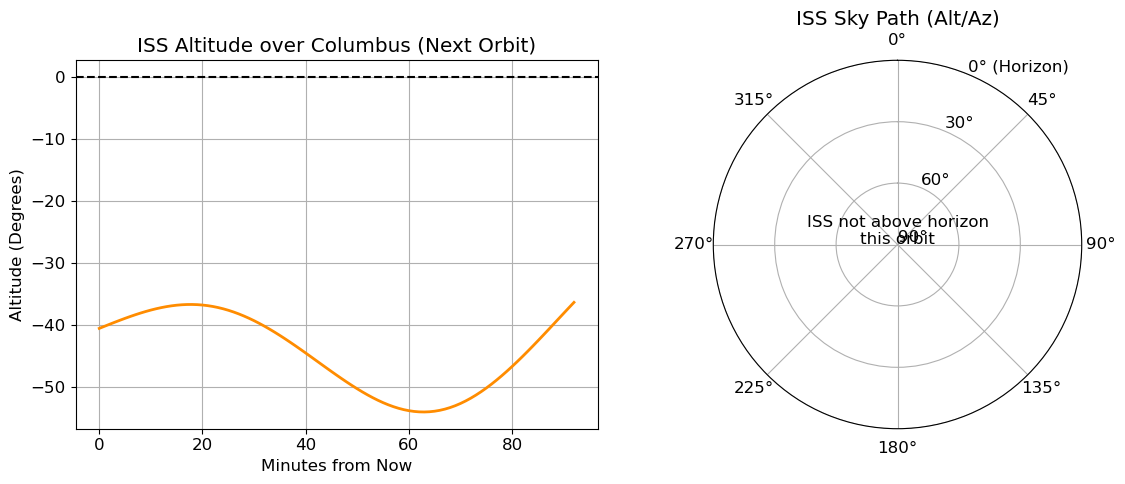

In [25]:
from skyfield.api import EarthSatellite

ts = load.timescale() 

# Fetch latest ISS TLE data from Celestrak
stations_url = 'https://celestrak.org/NORAD/elements/stations.txt'
satellites = load.tle_file(stations_url)
iss = {s.name: s for s in satellites}['ISS (ZARYA)']
columbus = wgs84.latlon(columbus_lat, columbus_lon, elevation_m=columbus_elev)

# Create a time range for the next orbit (~92 minutes)
t0 = ts.now()
minutes = np.arange(0, 93, 1) # One point every minute
t_range = ts.utc(t0.utc.year, t0.utc.month, t0.utc.day, t0.utc.hour, t0.utc.minute + minutes)

# 5. Calculate Alt/Az
difference = iss - columbus
topocentric = difference.at(t_range)
alt, az, distance = topocentric.altaz()

# 6. Plotting
fig = plt.figure(figsize=(12, 5))

# Plot A: Altitude vs Time
ax1 = fig.add_subplot(121)
ax1.plot(minutes, alt.degrees, color='darkorange', lw=2)
ax1.axhline(0, color='black', linestyle='--') # Horizon
ax1.fill_between(minutes, alt.degrees, 0, where=(alt.degrees > 0), color='gold', alpha=0.3)
ax1.set_title("ISS Altitude over Columbus (Next Orbit)")
ax1.set_xlabel("Minutes from Now")
ax1.set_ylabel("Altitude (Degrees)")
ax1.grid(True)

# Plot B: Sky Map (Polar Plot)
ax2 = fig.add_subplot(122, projection='polar')
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1) # Clockwise
ax2.set_rlim(0, 90)
ax2.set_yticks(range(0, 91, 30))
ax2.set_yticklabels(['90°', '60°', '30°', '0° (Horizon)']) # Invert for sky view

# Filter for points where ISS is above the horizon
mask = alt.degrees > 0
if any(mask):
    ax2.plot(az.radians[mask], 90 - alt.degrees[mask], 'o-', markersize=4, label='ISS Path')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, "ISS not above horizon\nthis orbit", transform=ax2.transAxes, ha='center')

ax2.set_title("ISS Sky Path (Alt/Az)")

plt.tight_layout()
plt.show()

**Test your understanding:** Find the Hubble Space Telescope in the database and create a similar plot. Note that HST is in a different file (below) of the 100 brightest satellites. 

Some other datasets are:
- Starlink: `https://celestrak.org/NORAD/elements/supplemental/starlink.txt`
- Weather Satellites: `https://celestrak.org/NORAD/elements/noaa.txt`
- GPS Satellites: `https://celestrak.org/NORAD/elements/gps-ops.txt`

In [26]:
visual_url = 'https://celestrak.org/NORAD/elements/visual.txt'
visual = load.tle_file(visual_url)
# Your solution here

[#################################] 100% visual.txt
